<a href="https://colab.research.google.com/github/yeshaa23/ZARA-AppsReview-SentimentAnalysis/blob/main/Week%204/Tugas_1C_TFIDF_Artikel_News.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Setup & Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [ ]:
#Input Artikel
#Artikel: Investasi Pertamina untuk Ketahanan dan Kedaulatan Energi Nasional (https://pasardana.id/news/2021/6/16/pertamina-optimalkan-strategi-investasi-di-seluruh-lini-bisnis/)

article_text = """
Upaya PT Pertamina (Persero) untuk menjalankan perannya sebagai pengelola energi nasional terus dioptimalkan melalui strategi investasi yang tepat di seluruh lini bisnis perusahaan.

Salah satunya di sektor hulu, sejak 2017 Pertamina mendapat kepercayaan dari pemerintah untuk mengambil alih 11 Wilayah Kerja Migas terminasi yang sebelumnya dikelola operator lain.

Pada Agustus 2021, ketika Blok Rokan resmi dikelola melalui Pertamina Hulu Rokan maka kontribusi Pertamina Group akan meningkat signifikan terhadap produksi migas nasional.

Dari realisasi investasi 2020 sebesar US$4,7 miliar, sektor hulu mendapat porsi tertinggi sebesar US$2,41 miliar atau 51%. Dan untuk menjaga pertumbuhan dan keberlanjutan bisnis di tahun 2021, Pertamina kembali menganggarkan Capital Expenditure (Capex) sebesar US$10,7 miliar.

“Langkah ini merupakan upaya perseroan untuk menjaga kedaulatan energi nasional dengan meningkatkan produksi minyak dan gas serta mendukung pemerintah mewujudkan produksi 1 juta barel,” ungkap Pjs Senior VP Corporate Communications & Investor Relations Pertamina, Fajriyah Usman, Rabu (16/6/2021).

Di sektor pengolahan, kata Fajriyah, anggaran investasi Pertamina juga diperuntukkan untuk membangun infrastruktur pengolahan 4 Refinery Development Master Plan (RDMP) dan 1 Grass Root Refinery (GRR) yang akan terintegrasi dengan kilang Petrokimia.

Sebagai kelanjutan dari implementasi program Biodiesel yang dijalankan sejak 2006, Pertamina juga berkomitmen mengembangkan Biofuel atau Biodiesel 100% dengan mempercepat penyelesaian proyek Biorefinery di 3 lokasi yakni kilang Cilacap, Dumai dan Plaju untuk memenuhi kebutuhan Biodiesel dengan mengolah sumber energi dari kelapa sawit yang melimpah di dalam negeri.

“Melalui investasi pembangunan kilang, Indonesia dapat mewujudkan swasembada atau kemandirian energi yang sangat diperlukan di masa depan,” ujarnya.

Lalu di sektor hilir, Fajriyah menuturkan, Pertamina juga terus mengembangkan infrastruktur penyaluran BBM, LPG, dan Gas. Saat ini, Pertamina sedang menuntaskan 14 lokasi Terminal BBM dan 4 lokasi Terminal LPG di Indonesia Timur.

Untuk mendorong upaya konversi energi bagi pembangkit listrik PLN, Pertamina juga membangun infrastruktur LNG di 56 titik.

“Mengantisipasi era transisi energi, Pertamina terus mengembangkan PLTP, PLTS atau PLTGU untuk ketahanan energi nasional,” imbuhnya.

Anggaran investasi untuk seluruh proyek tersebut bersumber dari internal ekuitas perusahaan maupun pembiayaan eksternal dalam bentuk pinjaman loan, global bond atau pendanaan proyek/project financing.

Dari keseluruhan proyek, yakni 14 Proyek Strategis Nasional dan 300 proyek investasi lainnya di sektor hulu, hilir, dan energi bersih terbarukan, Pertamina memerlukan sekitar US$92 miliar sepanjang 2020-2024.

“Melalui proyek dan pemanfaatan dana yang produktif ini, Pertamina dapat meningkatkan pendapatan perusahaan yang secara bertahap digunakan untuk membayar pinjaman,” kata Fajriyah.

Dalam rangka pengelolaan pinjaman, lanjut Fajriyah, Pertamina menjalankan beberapa strategi, di antaranya: disiplin pembentukan sinking fund, buyback global bond/liability management, cash management, akselerasi receivables collection antar perusahaan, serta disiplin monitoring hasil investasi.

Dengan strategi tersebut, perusahaan mampu merealisasikan kemampuan pembayaran obligasi yang jatuh tempo pada tahun 2021 sebesar US$391 juta. Sebelumnya tahun 2020, Pertamina juga telah melunasi tiga corporate loan dengan total mencapai US$549,4 juta.

Pada tahun 2020, Pertamina juga terbukti berhasil mencatat rasio utang yang terjaga dengan baik dan masih kompetitif di antara perusahaan migas nasional maupun internasional lainnya.

Tiga lembaga pemeringkat internasional yaitu Moody's, S&P dan Fitch menetapkan Pertamina pada peringkat investment grade masing-masing pada level Baa2, BBB, dan BBB.

“Kami melakukan upaya untuk tetap mempertahankan rasio utang dalam kontrol yang wajar sebagai perusahaan yang sehat. Debt to EBITDA tetap kita jaga, dan seluruh aspek keuangan juga dimonitor oleh KBUMN sebagai Pemegang Saham,” tandas Fajriyah.
"""

# Pecah artikel menjadi paragraf
paragraf = [p.strip() for p in article_text.strip().split('\n') if p.strip()]

print(f'Jumlah paragraf (dokumen): {len(paragraf)}')
print()
for i, p in enumerate(paragraf[:5]):
    print(f'  [{i}] {p[:90]}...')

Jumlah paragraf (dokumen): 19

  [0] Upaya PT Pertamina (Persero) untuk menjalankan perannya sebagai pengelola energi nasional ...
  [1] Salah satunya di sektor hulu, sejak 2017 Pertamina mendapat kepercayaan dari pemerintah un...
  [2] Pada Agustus 2021, ketika Blok Rokan resmi dikelola melalui Pertamina Hulu Rokan maka kont...
  [3] Dari realisasi investasi 2020 sebesar US$4,7 miliar, sektor hulu mendapat porsi tertinggi ...
  [4] “Langkah ini merupakan upaya perseroan untuk menjaga kedaulatan energi nasional dengan men...


In [ ]:
#Preprocessing

stopword_id = {
    'dan', 'di', 'ke', 'dari', 'yang', 'untuk', 'pada', 'dengan', 'juga', 'atau',
    'ini', 'itu', 'dalam', 'oleh', 'sebagai', 'akan', 'telah', 'lebih', 'bagi',
    'yakni', 'agar', 'saat', 'masih', 'terus', 'melalui', 'serta', 'hingga',
    'karena', 'antara', 'adalah', 'kita', 'dapat', 'maupun', 'sejak', 'lainnya',
    'seluruh', 'tetap', 'lain', 'sangat', 'tahun'
}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # hapus angka & tanda baca
    text = re.sub(r'\s+', ' ', text).strip() # hapus spasi berlebih
    return text

paragraf_clean = [clean_text(p) for p in paragraf]

print('Contoh sebelum dan sesudah preprocessing:')
print(f'SEBELUM: {paragraf[0][:100]}...')
print(f'SESUDAH : {paragraf_clean[0][:100]}...')

Contoh sebelum dan sesudah preprocessing:
SEBELUM: Upaya PT Pertamina (Persero) untuk menjalankan perannya sebagai pengelola energi nasional terus diop...
SESUDAH : upaya pt pertamina persero untuk menjalankan perannya sebagai pengelola energi nasional terus diopti...


In [ ]:
#Bag of Words
vectorizer_bow = CountVectorizer()
matriks_bow = vectorizer_bow.fit_transform(paragraf_clean)

daftar_kata = vectorizer_bow.get_feature_names_out()

print(f'BoW Matrix   : {matriks_bow.shape} (paragraf x kata unik)')
print(f'Vocabulary   : {len(daftar_kata)} kata unik')

jumlah_kata = np.asarray(matriks_bow.sum(axis=0)).flatten()
urutan_bow = jumlah_kata.argsort()[::-1][:15]

print('\nTop 15 kata (BoW - frekuensi mentah):')
for idx in urutan_bow:
    print(f'  {daftar_kata[idx]:20s} -> {int(jumlah_kata[idx])}')

BoW Matrix   : (19, 285) (paragraf x kata unik)
Vocabulary   : 285 kata unik

Top 15 kata (BoW - frekuensi mentah):
  pertamina            -> 18
  dan                  -> 14
  di                   -> 13
  yang                 -> 12
  untuk                -> 11
  energi               -> 8
  dengan               -> 7
  proyek               -> 7
  perusahaan           -> 7
  juga                 -> 7
  investasi            -> 7
  fajriyah             -> 6
  us                   -> 6
  dari                 -> 6
  nasional             -> 6


In [ ]:
#TF-IDF
# 5. TF-IDF (TfidfTransformer)

pembobot_tfidf = TfidfTransformer()
matriks_tfidf = pembobot_tfidf.fit_transform(matriks_bow)

print(f'TF-IDF Matrix: {matriks_tfidf.shape}')

rata_tfidf = np.asarray(matriks_tfidf.mean(axis=0)).flatten()
urutan_tfidf = rata_tfidf.argsort()[::-1][:15]

print('\nTop 15 kata (TF-IDF - rata-rata bobot):')
for idx in urutan_tfidf:
    print(f'  {daftar_kata[idx]:20s} -> {rata_tfidf[idx]:.4f}')

TF-IDF Matrix: (19, 285)

Top 15 kata (TF-IDF - rata-rata bobot):
  pertamina            -> 0.0730
  dan                  -> 0.0711
  yang                 -> 0.0705
  di                   -> 0.0670
  energi               -> 0.0609
  untuk                -> 0.0596
  proyek               -> 0.0592
  nasional             -> 0.0474
  perusahaan           -> 0.0473
  investasi            -> 0.0471
  dengan               -> 0.0466
  us                   -> 0.0461
  juga                 -> 0.0444
  dari                 -> 0.0414
  pada                 -> 0.0410


In [ ]:
#Bigram Analysis
phrase_extractor = CountVectorizer(ngram_range=(2, 2), min_df=1)
phrase_matrix = phrase_extractor.fit_transform(paragraf_clean)

phrases = phrase_extractor.get_feature_names_out()
phrase_counts = np.asarray(phrase_matrix.sum(axis=0)).ravel()

top_phrase_idx = phrase_counts.argsort()[::-1][:15]

print("Top 15 bigram/frasa penting:")
for posisi in top_phrase_idx:
    print(f"{phrases[posisi]:35s} {int(phrase_counts[posisi])}")

Top 15 bigram/frasa penting:
pertamina juga                      6
us miliar                           4
di sektor                           4
sebesar us                          4
sektor hulu                         3
energi nasional                     3
tahun pertamina                     3
us juta                             2
anggaran investasi                  2
migas nasional                      2
lokasi terminal                     2
perusahaan yang                     2
terus mengembangkan                 2
rasio utang                         2
dan gas                             2


In [ ]:
print(len(daftar_kata))
print(len(jumlah_kata))
print(len(rata_tfidf))

285
285
285


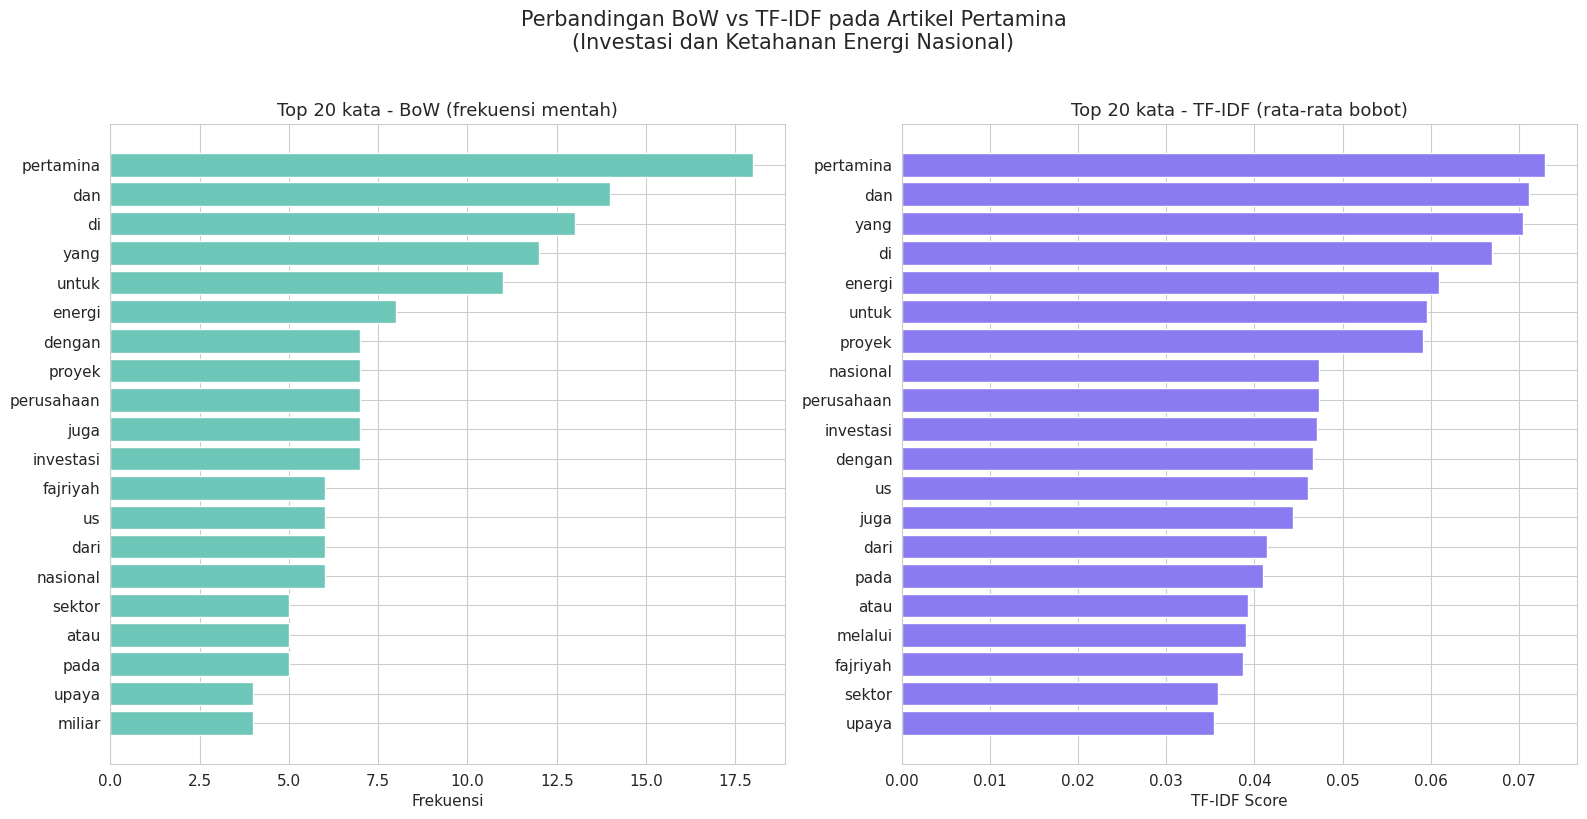

In [ ]:
# 6. Perbandingan BoW vs TF-IDF

top20_bow = jumlah_kata.argsort()[::-1][:20]
top20_tfidf = rata_tfidf.argsort()[::-1][:20]

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# BoW
kata_bow = [daftar_kata[i] for i in top20_bow]
nilai_bow = [int(jumlah_kata[i]) for i in top20_bow]
ax[0].barh(kata_bow[::-1], nilai_bow[::-1], color='#6EC6B8', edgecolor='white')
ax[0].set_title('Top 20 kata - BoW (frekuensi mentah)', fontsize=13)
ax[0].set_xlabel('Frekuensi')

# TF-IDF
kata_tfidf = [daftar_kata[i] for i in top20_tfidf]
nilai_tfidf = [rata_tfidf[i] for i in top20_tfidf]
ax[1].barh(kata_tfidf[::-1], nilai_tfidf[::-1], color='#8A7CF0', edgecolor='white')
ax[1].set_title('Top 20 kata - TF-IDF (rata-rata bobot)', fontsize=13)
ax[1].set_xlabel('TF-IDF Score')

plt.suptitle('Perbandingan BoW vs TF-IDF pada Artikel Pertamina\n(Investasi dan Ketahanan Energi Nasional)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# 7. Tabel Perbandingan Side-by-Side

print(f'{"Rank":>4}  {"BoW (kata)":20s} {"Freq":>5}  |  {"TF-IDF (kata)":20s} {"Score":>8}')
print('-' * 72)

for rank in range(15):
    idx_b = top20_bow[rank]
    idx_t = top20_tfidf[rank]
    print(f'{rank+1:>4}  {daftar_kata[idx_b]:20s} {int(jumlah_kata[idx_b]):>5}  |  {daftar_kata[idx_t]:20s} {rata_tfidf[idx_t]:>8.4f}')

Rank  BoW (kata)            Freq  |  TF-IDF (kata)           Score
------------------------------------------------------------------------
   1  pertamina               18  |  pertamina              0.0730
   2  dan                     14  |  dan                    0.0711
   3  di                      13  |  yang                   0.0705
   4  yang                    12  |  di                     0.0670
   5  untuk                   11  |  energi                 0.0609
   6  energi                   8  |  untuk                  0.0596
   7  dengan                   7  |  proyek                 0.0592
   8  proyek                   7  |  nasional               0.0474
   9  perusahaan               7  |  perusahaan             0.0473
  10  juga                     7  |  investasi              0.0471
  11  investasi                7  |  dengan                 0.0466
  12  fajriyah                 6  |  us                     0.0461
  13  us                       6  |  juga               

In [12]:
# 8. Analisis per Paragraf
# Menampilkan kata terpenting di tiap paragraf berdasarkan TF-IDF

print('Kata terpenting per paragraf (TF-IDF):')
print('=' * 85)

for i in range(min(10, len(paragraf))):
    baris = np.asarray(matriks_tfidf[i].todense()).flatten()
    top3_idx = baris.argsort()[::-1][:3]
    keyword = ', '.join([f'{daftar_kata[idx]} ({baris[idx]:.3f})' for idx in top3_idx if baris[idx] > 0])

    print(f'  [{i:2d}] {paragraf[i][:60]}...')
    print(f'       Keywords: {keyword}')
    print()

Kata terpenting per paragraf (TF-IDF):
  [ 0] Upaya PT Pertamina (Persero) untuk menjalankan perannya seba...
       Keywords: dioptimalkan (0.265), tepat (0.265), persero (0.265)

  [ 1] Salah satunya di sektor hulu, sejak 2017 Pertamina mendapat ...
       Keywords: mengambil (0.245), salah (0.245), lain (0.245)

  [ 2] Pada Agustus 2021, ketika Blok Rokan resmi dikelola melalui ...
       Keywords: rokan (0.454), maka (0.227), meningkat (0.227)

  [ 3] Dari realisasi investasi 2020 sebesar US$4,7 miliar, sektor ...
       Keywords: miliar (0.438), sebesar (0.438), us (0.395)

  [ 4] “Langkah ini merupakan upaya perseroan untuk menjaga kedaula...
       Keywords: produksi (0.329), pjs (0.187), perseroan (0.187)

  [ 5] Di sektor pengolahan, kata Fajriyah, anggaran investasi Pert...
       Keywords: pengolahan (0.398), refinery (0.398), diperuntukkan (0.199)

  [ 6] Sebagai kelanjutan dari implementasi program Biodiesel yang ...
       Keywords: biodiesel (0.466), dari (0.208), dengan